In [1]:
# ============================================
# Household Load Forecasting Pipeline
# ============================================
# This notebook:
# 1. Loads the household 15-minute dataset
# 2. Converts cumulative meter readings into interval-based load
# 3. Builds forecasting features for one selected household
# 4. Trains and compares single-step baseline models
# 5. Builds a direct multi-step 24-hour forecasting model
# 6. Tunes, evaluates, and saves the final model
# ============================================

# ----------------------------
# 1. Import required libraries
# ----------------------------
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


In [2]:
# ----------------------------
# 2. Load the raw dataset
# ----------------------------
df = pd.read_csv("../data/household_data_15min_singleindex.csv")

print("Raw dataset shape:", df.shape)
display(df.head())

Raw dataset shape: (153810, 71)


,utc_timestamp,cet_cest_timestamp,DE_KN_industrial1_grid_import,DE_KN_industrial1_pv_1,DE_KN_industrial1_pv_2,DE_KN_industrial2_grid_import,DE_KN_industrial2_pv,DE_KN_industrial2_storage_charge,DE_KN_industrial2_storage_decharge,DE_KN_industrial3_area_offices,...,DE_KN_residential5_refrigerator,DE_KN_residential5_washing_machine,DE_KN_residential6_circulation_pump,DE_KN_residential6_dishwasher,DE_KN_residential6_freezer,DE_KN_residential6_grid_export,DE_KN_residential6_grid_import,DE_KN_residential6_pv,DE_KN_residential6_washing_machine,interpolated
0,2014-12-11T17:45:00Z,2014-12-11T18:45:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-12-11T18:00:00Z,2014-12-11T19:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014-12-11T18:15:00Z,2014-12-11T19:15:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014-12-11T18:30:00Z,2014-12-11T19:30:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014-12-11T18:45:00Z,2014-12-11T19:45:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# ----------------------------
# 3. Prepare timestamp index
# ----------------------------
df["cet_cest_timestamp"] = pd.to_datetime(df["cet_cest_timestamp"])
df = df.set_index("cet_cest_timestamp").sort_index()

print("Index dtype:", df.index.dtype)
display(df.head())

Index dtype: object


,utc_timestamp,DE_KN_industrial1_grid_import,DE_KN_industrial1_pv_1,DE_KN_industrial1_pv_2,DE_KN_industrial2_grid_import,DE_KN_industrial2_pv,DE_KN_industrial2_storage_charge,DE_KN_industrial2_storage_decharge,DE_KN_industrial3_area_offices,DE_KN_industrial3_area_room_1,...,DE_KN_residential5_refrigerator,DE_KN_residential5_washing_machine,DE_KN_residential6_circulation_pump,DE_KN_residential6_dishwasher,DE_KN_residential6_freezer,DE_KN_residential6_grid_export,DE_KN_residential6_grid_import,DE_KN_residential6_pv,DE_KN_residential6_washing_machine,interpolated
cet_cest_timestamp,,,,,,,,,,,,,,,,,,,,,
2014-12-11 18:45:00+01:00,2014-12-11T17:45:00Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 19:00:00+01:00,2014-12-11T18:00:00Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 19:15:00+01:00,2014-12-11T18:15:00Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 19:30:00+01:00,2014-12-11T18:30:00Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 19:45:00+01:00,2014-12-11T18:45:00Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# ---------------------------------------------------------
# 4. Exploratory direct load construction (not final logic)
# ---------------------------------------------------------
# Note:
# This first version directly combines cumulative signals and is used
# only for initial inspection. It is NOT the final load used later.
residential_ids = [1, 2, 3, 4, 5, 6]

load_df = pd.DataFrame(index=df.index)

for house_id in residential_ids:
    grid_import_col = f"DE_KN_residential{house_id}_grid_import"
    pv_col = f"DE_KN_residential{house_id}_pv"
    grid_export_col = f"DE_KN_residential{house_id}_grid_export"

    grid_import = df[grid_import_col] if grid_import_col in df.columns else 0.0
    pv = df[pv_col] if pv_col in df.columns else 0.0
    grid_export = df[grid_export_col] if grid_export_col in df.columns else 0.0

    load_df[f"residential{house_id}_load"] = grid_import + pv - grid_export

display(load_df.head())
display(load_df.describe())
display(load_df.max())

# Convert to kW scale for easier inspection
load_df = load_df / 1000
display(load_df.describe())

nan_summary = pd.DataFrame({
    "nan_count": load_df.isna().sum(),
    "nan_percent": 100 * load_df.isna().sum() / len(load_df)
})

display(nan_summary)


,residential1_load,residential2_load,residential3_load,residential4_load,residential5_load,residential6_load
cet_cest_timestamp,,,,,,
2014-12-11 18:45:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 19:00:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 19:15:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 19:30:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 19:45:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN


,residential1_load,residential2_load,residential3_load,residential4_load,residential5_load,residential6_load
count,63487.000000,63190.000000,47612.000000,81435.000000,123211.000000,66755.000000
mean,13779.846119,2017.367027,3733.514971,7611.200361,4690.002662,15442.822022
std,7420.930370,1276.663640,2179.448629,4300.431896,2612.395098,5262.700005
min,0.085000,0.000000,0.044000,0.013000,0.020000,6243.700000
25%,7929.616000,843.123250,1926.089500,4338.875500,2254.466000,11102.427000
50%,12720.016000,1988.908000,3637.930500,7114.778000,4758.691000,15420.064000
75%,21331.149500,3055.754250,5526.456750,11445.450000,7195.781500,20338.923000
max,25618.242000,4495.448000,8324.087000,15752.780000,8773.800000,24401.449000


residential1_load    25618.242
residential2_load     4495.448
residential3_load     8324.087
residential4_load    15752.780
residential5_load     8773.800
residential6_load    24401.449
dtype: float64

,residential1_load,residential2_load,residential3_load,residential4_load,residential5_load,residential6_load
count,63487.000000,63190.000000,47612.000000,81435.000000,123211.000000,66755.000000
mean,13.779846,2.017367,3.733515,7.611200,4.690003,15.442822
std,7.420930,1.276664,2.179449,4.300432,2.612395,5.262700
min,0.000085,0.000000,0.000044,0.000013,0.000020,6.243700
25%,7.929616,0.843123,1.926090,4.338876,2.254466,11.102427
50%,12.720016,1.988908,3.637931,7.114778,4.758691,15.420064
75%,21.331149,3.055754,5.526457,11.445450,7.195781,20.338923
max,25.618242,4.495448,8.324087,15.752780,8.773800,24.401449


,nan_count,nan_percent
residential1_load,90323,58.723750
residential2_load,90620,58.916845
residential3_load,106198,69.044926
residential4_load,72375,47.054808
residential5_load,30599,19.894025
residential6_load,87055,56.599051


In [5]:
# -------------------------------------------------------------------
# 5. Exploratory extraction of household load series (not final logic)
# -------------------------------------------------------------------
house_data = {}

for house_id in residential_ids:
    col = f"residential{house_id}_load"
    house_df = load_df[[col]].dropna().copy()
    house_df = house_df.rename(columns={col: "load"})
    house_data[house_id] = house_df

for house_id in residential_ids:
    print(f"House {house_id}: {house_data[house_id].shape}")


House 1: (63487, 1)
House 2: (63190, 1)
House 3: (47612, 1)
House 4: (81435, 1)
House 5: (123211, 1)
House 6: (66755, 1)


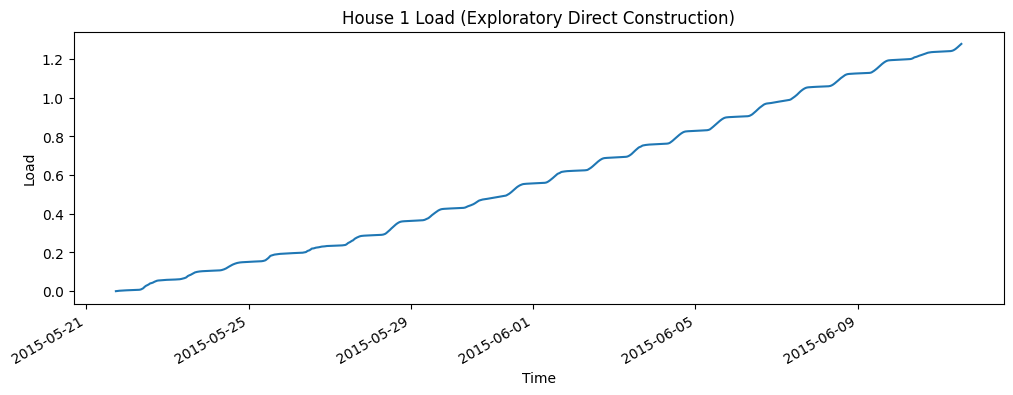

In [6]:
# ------------------------------------------------------------
# 6. Plot exploratory direct load for one house before fixing
# ------------------------------------------------------------
house_data[1]["load"].iloc[:2000].plot(figsize=(12, 4))
plt.title("House 1 Load (Exploratory Direct Construction)")
plt.xlabel("Time")
plt.ylabel("Load")
plt.show()


In [7]:
# -------------------------------------------------------
# 7. Sanity check on one household using differenced data
# -------------------------------------------------------
house_id = 1

grid_import_col = f"DE_KN_residential{house_id}_grid_import"
pv_col = f"DE_KN_residential{house_id}_pv"
grid_export_col = f"DE_KN_residential{house_id}_grid_export"

house1 = df[[grid_import_col]].copy()

if pv_col in df.columns:
    house1[pv_col] = df[pv_col]
else:
    house1[pv_col] = 0.0

if grid_export_col in df.columns:
    house1[grid_export_col] = df[grid_export_col]
else:
    house1[grid_export_col] = 0.0

house1 = house1.sort_index()
display(house1.head())

,DE_KN_residential1_grid_import,DE_KN_residential1_pv,DE_KN_residential1_grid_export
cet_cest_timestamp,,,
2014-12-11 18:45:00+01:00,NaN,NaN,0.0
2014-12-11 19:00:00+01:00,NaN,NaN,0.0
2014-12-11 19:15:00+01:00,NaN,NaN,0.0
2014-12-11 19:30:00+01:00,NaN,NaN,0.0
2014-12-11 19:45:00+01:00,NaN,NaN,0.0


In [8]:
# -------------------------------------------------------
# 8. Convert cumulative signals into interval-based values
# -------------------------------------------------------
house1_diff = house1.diff()
display(house1_diff.head())


,DE_KN_residential1_grid_import,DE_KN_residential1_pv,DE_KN_residential1_grid_export
cet_cest_timestamp,,,
2014-12-11 18:45:00+01:00,NaN,NaN,NaN
2014-12-11 19:00:00+01:00,NaN,NaN,0.0
2014-12-11 19:15:00+01:00,NaN,NaN,0.0
2014-12-11 19:30:00+01:00,NaN,NaN,0.0
2014-12-11 19:45:00+01:00,NaN,NaN,0.0


In [10]:
# ---------------------------------------
# 9. Build interval-based household load
# ---------------------------------------
house1_diff["load"] = (
    house1_diff[grid_import_col]
    + house1_diff[pv_col]
    - house1_diff[grid_export_col]
)

# Remove negative artifacts and initial NaN
house1_diff["load"] = house1_diff["load"].clip(lower=0)
house1_load = house1_diff[["load"]].dropna().copy()

display(house1_load.head())

,load
cet_cest_timestamp,
2015-05-21 17:45:00+02:00,0.157
2015-05-21 18:00:00+02:00,0.273
2015-05-21 18:15:00+02:00,0.311
2015-05-21 18:30:00+02:00,0.280
2015-05-21 18:45:00+02:00,0.265


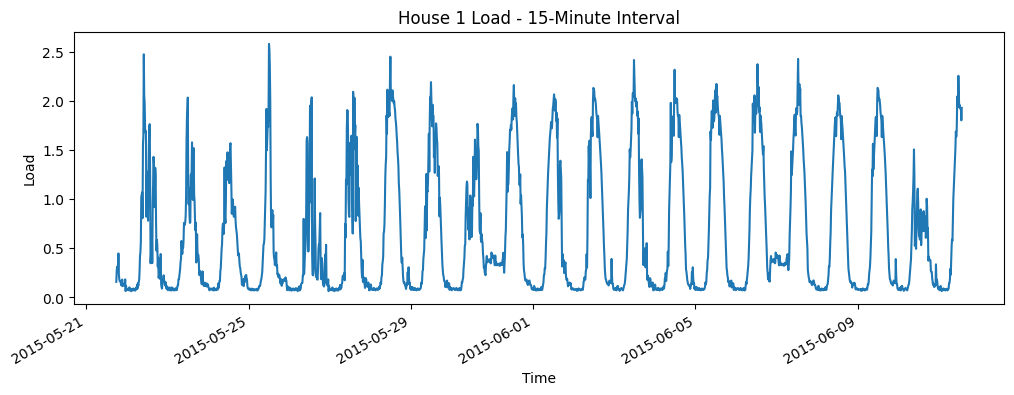

In [11]:
# --------------------------------------
# 10. Visual sanity check for final load
# --------------------------------------
house1_load["load"].iloc[:2000].plot(figsize=(12, 4))
plt.title("House 1 Load - 15-Minute Interval")
plt.xlabel("Time")
plt.ylabel("Load")
plt.show()

In [12]:
# --------------------------------------------------
# 11. Inspect statistics and interval consistency
# --------------------------------------------------
display(house1_load["load"].describe())
display(house1_load.index.to_series().diff().value_counts().head())

count    63486.000000
mean         0.403525
std          0.502228
min          0.029000
25%          0.105000
50%          0.165000
75%          0.449000
max          3.198000
Name: load, dtype: float64

cet_cest_timestamp
0 days 00:15:00    63485
Name: count, dtype: int64

In [13]:
# ---------------------------------------------------------
# 12. Build final interval-based load for all households
# ---------------------------------------------------------
house_data = {}

for house_id in residential_ids:
    grid_import_col = f"DE_KN_residential{house_id}_grid_import"
    pv_col = f"DE_KN_residential{house_id}_pv"
    grid_export_col = f"DE_KN_residential{house_id}_grid_export"

    house_df = df[[grid_import_col]].copy()

    if pv_col in df.columns:
        house_df[pv_col] = df[pv_col]
    else:
        house_df[pv_col] = 0.0

    if grid_export_col in df.columns:
        house_df[grid_export_col] = df[grid_export_col]
    else:
        house_df[grid_export_col] = 0.0

    house_df = house_df.sort_index()

    house_diff = house_df.diff()

    house_diff["load"] = (
        house_diff[grid_import_col]
        + house_diff[pv_col]
        - house_diff[grid_export_col]
    )

    house_diff["load"] = house_diff["load"].clip(lower=0)
    house_load = house_diff[["load"]].dropna().copy()

    house_data[house_id] = house_load

for house_id in residential_ids:
    print(f"House {house_id}: {house_data[house_id].shape}")

House 1: (63486, 1)
House 2: (63189, 1)
House 3: (47611, 1)
House 4: (81434, 1)
House 5: (123210, 1)
House 6: (66754, 1)


In [14]:
# -------------------------------------------------------
# 13. Select one household for forecasting experiments
# -------------------------------------------------------
house_id = 1
df_house = house_data[house_id].copy()

display(df_house.head())

,load
cet_cest_timestamp,
2015-05-21 17:45:00+02:00,0.157
2015-05-21 18:00:00+02:00,0.273
2015-05-21 18:15:00+02:00,0.311
2015-05-21 18:30:00+02:00,0.280
2015-05-21 18:45:00+02:00,0.265


In [16]:
# ------------------------------------------
# 14. Convert index to timezone-aware format
# ------------------------------------------
df_house.index = pd.to_datetime(df_house.index, utc=True)
print(type(df_house.index))

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [17]:
# -----------------------------------
# 15. Create initial calendar features
# -----------------------------------
df_house["hour"] = df_house.index.hour
df_house["day_of_week"] = df_house.index.dayofweek
df_house["month"] = df_house.index.month
df_house["is_weekend"] = (df_house["day_of_week"] >= 5).astype(int)

display(df_house.head())

,load,hour,day_of_week,month,is_weekend
cet_cest_timestamp,,,,,
2015-05-21 15:45:00+00:00,0.157,15,3,5,0
2015-05-21 16:00:00+00:00,0.273,16,3,5,0
2015-05-21 16:15:00+00:00,0.311,16,3,5,0
2015-05-21 16:30:00+00:00,0.280,16,3,5,0
2015-05-21 16:45:00+00:00,0.265,16,3,5,0


In [18]:
# --------------------------
# 16. Create lag features
# --------------------------
df_house["lag_1"] = df_house["load"].shift(1)      # 15 minutes ago
df_house["lag_4"] = df_house["load"].shift(4)      # 1 hour ago
df_house["lag_96"] = df_house["load"].shift(96)    # 24 hours ago

display(df_house.head())

,load,hour,day_of_week,month,is_weekend,lag_1,lag_4,lag_96
cet_cest_timestamp,,,,,,,,
2015-05-21 15:45:00+00:00,0.157,15,3,5,0,NaN,NaN,NaN
2015-05-21 16:00:00+00:00,0.273,16,3,5,0,0.157,NaN,NaN
2015-05-21 16:15:00+00:00,0.311,16,3,5,0,0.273,NaN,NaN
2015-05-21 16:30:00+00:00,0.280,16,3,5,0,0.311,NaN,NaN
2015-05-21 16:45:00+00:00,0.265,16,3,5,0,0.280,0.157,NaN


In [ ]:
# --------------------------------------------
# 17. Drop rows with missing lag values
# --------------------------------------------
df_house = df_house.dropna()
display(df_house.head())

,load,hour,day_of_week,month,is_weekend,lag_1,lag_4,lag_96
cet_cest_timestamp,,,,,,,,
2015-05-22 15:45:00+00:00,0.584,15,4,5,0,0.475,1.318,0.157
2015-05-22 16:00:00+00:00,0.529,16,4,5,0,0.584,1.231,0.273
2015-05-22 16:15:00+00:00,0.313,16,4,5,0,0.529,0.754,0.311
2015-05-22 16:30:00+00:00,0.403,16,4,5,0,0.313,0.475,0.280
2015-05-22 16:45:00+00:00,0.200,16,4,5,0,0.403,0.584,0.265


In [ ]:
# -------------------------------
# 18. Create rolling mean features
# -------------------------------
df_house["rolling_mean_1h"] = df_house["load"].rolling(4).mean()
df_house["rolling_mean_24h"] = df_house["load"].rolling(96).mean()

display(df_house.head())


,load,hour,day_of_week,month,is_weekend,lag_1,lag_4,lag_96,rolling_mean_1h,rolling_mean_24h
cet_cest_timestamp,,,,,,,,,,
2015-05-22 15:45:00+00:00,0.584,15,4,5,0,0.475,1.318,0.157,NaN,NaN
2015-05-22 16:00:00+00:00,0.529,16,4,5,0,0.584,1.231,0.273,NaN,NaN
2015-05-22 16:15:00+00:00,0.313,16,4,5,0,0.529,0.754,0.311,NaN,NaN
2015-05-22 16:30:00+00:00,0.403,16,4,5,0,0.313,0.475,0.280,0.45725,NaN
2015-05-22 16:45:00+00:00,0.200,16,4,5,0,0.403,0.584,0.265,0.36125,NaN


In [ ]:
# ------------------------------------------------
# 19. Drop rows with missing rolling values
# ------------------------------------------------
df_house = df_house.dropna()

display(df_house.head())
print("Final feature-engineered dataset shape:", df_house.shape)


,load,hour,day_of_week,month,is_weekend,lag_1,lag_4,lag_96,rolling_mean_1h,rolling_mean_24h
cet_cest_timestamp,,,,,,,,,,
2015-05-23 15:30:00+00:00,0.642,15,5,5,1,0.374,0.682,0.475,0.53250,0.483885
2015-05-23 15:45:00+00:00,0.456,15,5,5,1,0.642,0.760,0.584,0.45650,0.482552
2015-05-23 16:00:00+00:00,0.431,16,5,5,1,0.456,0.354,0.529,0.47575,0.481531
2015-05-23 16:15:00+00:00,0.431,16,5,5,1,0.431,0.374,0.313,0.49000,0.482760
2015-05-23 16:30:00+00:00,0.381,16,5,5,1,0.431,0.642,0.403,0.42475,0.482531


Final feature-engineered dataset shape: (63295, 10)


In [22]:
# ---------------------------------------------------------
# 20. Build single-step target for 24-hour-ahead forecasting
# ---------------------------------------------------------
# 96 steps = 24 hours because data is sampled every 15 minutes
df_house["target"] = df_house["load"].shift(-96)
df_house = df_house.dropna()

display(df_house.head())

,load,hour,day_of_week,month,is_weekend,lag_1,lag_4,lag_96,rolling_mean_1h,rolling_mean_24h,target
cet_cest_timestamp,,,,,,,,,,,
2015-05-23 15:30:00+00:00,0.642,15,5,5,1,0.374,0.682,0.475,0.53250,0.483885,0.488
2015-05-23 15:45:00+00:00,0.456,15,5,5,1,0.642,0.760,0.584,0.45650,0.482552,0.426
2015-05-23 16:00:00+00:00,0.431,16,5,5,1,0.456,0.354,0.529,0.47575,0.481531,0.451
2015-05-23 16:15:00+00:00,0.431,16,5,5,1,0.431,0.374,0.313,0.49000,0.482760,0.440
2015-05-23 16:30:00+00:00,0.381,16,5,5,1,0.431,0.642,0.403,0.42475,0.482531,0.366


In [23]:
# -----------------------------------------
# 21. Separate features and target variable
# -----------------------------------------
X = df_house.drop(columns=["load", "target"])
y = df_house["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (63199, 9)
y shape: (63199,)


In [24]:
# --------------------------------------------------
# 22. Chronological train / validation / test split
# --------------------------------------------------
n = len(X)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


Train: (44239, 9) (44239,)
Validation: (9480, 9) (9480,)
Test: (9480, 9) (9480,)


In [25]:
# ---------------------------------------------
# 23. Define single-step baseline regression models
# ---------------------------------------------
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "DecisionTree": DecisionTreeRegressor(),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42)
}

In [26]:
# ---------------------------------------------
# 24. Train and evaluate baseline models
# ---------------------------------------------
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))

    results.append({
        "model": name,
        "MAE": mae,
        "RMSE": rmse
    })

results_df = pd.DataFrame(results).sort_values("RMSE")
display(results_df)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000253 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1321
[LightGBM] [Info] Number of data points in the train set: 44239, number of used features: 9
[LightGBM] [Info] Start training from score 0.444155


c:\Users\Mehdi Zamani\.pyenv\pyenv-win\versions\3.11.3\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Mehdi Zamani\.pyenv\pyenv-win\versions\3.11.3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Mehdi Zamani\.pyenv\pyenv-win\versions\3.11.3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Mehdi Zamani\.pyenv\pyenv-win\versions\3.11.3\Lib\subprocess.py", l

,model,MAE,RMSE
5,LightGBM,0.141673,0.256877
0,LinearRegression,0.154428,0.259658
1,Ridge,0.154431,0.259658
3,RandomForest,0.150178,0.267204
4,XGBoost,0.148803,0.276513
2,DecisionTree,0.191512,0.357134


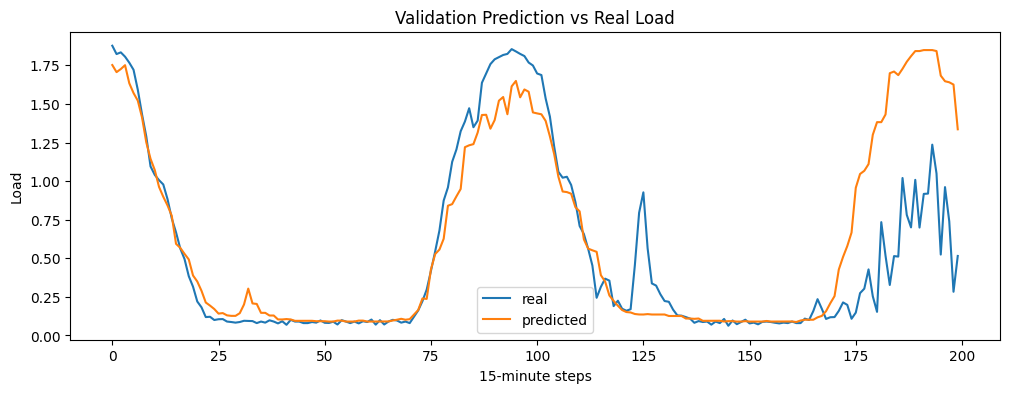

In [27]:
# -----------------------------------------------------------
# 25. Visual comparison for the best single-step baseline
# -----------------------------------------------------------
best_model = models["LightGBM"]
y_val_pred = best_model.predict(X_val)

plt.figure(figsize=(12, 4))
plt.plot(y_val.values[:200], label="real")
plt.plot(y_val_pred[:200], label="predicted")
plt.legend()
plt.title("Validation Prediction vs Real Load")
plt.xlabel("15-minute steps")
plt.ylabel("Load")
plt.show()

In [28]:
# -------------------------------------------------------
# 26. Build direct multi-step targets for next 24 hours
# -------------------------------------------------------
horizon = 96
y_multi = pd.DataFrame(index=df_house.index)

for h in range(1, horizon + 1):
    y_multi[f"target_t+{h}"] = df_house["load"].shift(-h)

display(y_multi.head())

,target_t+1,target_t+2,target_t+3,target_t+4,target_t+5,target_t+6,target_t+7,target_t+8,target_t+9,target_t+10,...,target_t+87,target_t+88,target_t+89,target_t+90,target_t+91,target_t+92,target_t+93,target_t+94,target_t+95,target_t+96
cet_cest_timestamp,,,,,,,,,,,,,,,,,,,,,
2015-05-23 15:30:00+00:00,0.456,0.431,0.431,0.381,0.227,0.241,0.267,0.242,0.204,0.146,...,0.819,0.838,0.891,0.921,0.780,0.711,0.677,0.644,0.575,0.488
2015-05-23 15:45:00+00:00,0.431,0.431,0.381,0.227,0.241,0.267,0.242,0.204,0.146,0.133,...,0.838,0.891,0.921,0.780,0.711,0.677,0.644,0.575,0.488,0.426
2015-05-23 16:00:00+00:00,0.431,0.381,0.227,0.241,0.267,0.242,0.204,0.146,0.133,0.144,...,0.891,0.921,0.780,0.711,0.677,0.644,0.575,0.488,0.426,0.451
2015-05-23 16:15:00+00:00,0.381,0.227,0.241,0.267,0.242,0.204,0.146,0.133,0.144,0.263,...,0.921,0.780,0.711,0.677,0.644,0.575,0.488,0.426,0.451,0.440
2015-05-23 16:30:00+00:00,0.227,0.241,0.267,0.242,0.204,0.146,0.133,0.144,0.263,0.130,...,0.780,0.711,0.677,0.644,0.575,0.488,0.426,0.451,0.440,0.366


In [29]:
# --------------------------------------------------------
# 27. Align feature matrix with multi-step target matrix
# --------------------------------------------------------
data_multi = pd.concat([X, y_multi], axis=1).dropna()
print("Aligned multi-step dataset shape:", data_multi.shape)

Aligned multi-step dataset shape: (63103, 105)


In [30]:
# ---------------------------------------------------
# 28. Separate multi-step inputs and targets
# ---------------------------------------------------
X_multi = data_multi[X.columns]
y_multi = data_multi[y_multi.columns]

print("X_multi shape:", X_multi.shape)
print("y_multi shape:", y_multi.shape)

X_multi shape: (63103, 9)
y_multi shape: (63103, 96)


In [31]:
# ---------------------------------------------------------
# 29. Chronological split for multi-step forecasting
# ---------------------------------------------------------
n = len(X_multi)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X_multi.iloc[:train_end]
y_train = y_multi.iloc[:train_end]

X_val = X_multi.iloc[train_end:val_end]
y_val = y_multi.iloc[train_end:val_end]

X_test = X_multi.iloc[val_end:]
y_test = y_multi.iloc[val_end:]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (44172, 9) (44172, 96)
Validation: (9465, 9) (9465, 96)
Test: (9466, 9) (9466, 96)


In [32]:
# ---------------------------------------------------------
# 30. Train baseline multi-output LightGBM model
# ---------------------------------------------------------
multi_lgbm = MultiOutputRegressor(
    LGBMRegressor(
        n_estimators=100,
        random_state=42
    )
)

multi_lgbm.fit(X_train, y_train)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000491 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1321
[LightGBM] [Info] Number of data points in the train set: 44172, number of used features: 9
[LightGBM] [Info] Start training from score 0.443631
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000951 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1321
[LightGBM] [Info] Number of data points in the train set: 44172, number of used features: 9
[LightGBM] [Info] Start training from score 0.443624
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000246 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins

MultiOutputRegressor(estimator=LGBMRegressor(random_state=42))

In [33]:
# ---------------------------------------------------------
# 31. Generate validation forecasts for all 96 steps
# ---------------------------------------------------------
y_val_pred = multi_lgbm.predict(X_val)
print("Validation prediction shape:", y_val_pred.shape)

Validation prediction shape: (9465, 96)


In [34]:
# ---------------------------------------------------------
# 32. Compute overall multi-step validation metrics
# ---------------------------------------------------------
mae = mean_absolute_error(y_val.values.flatten(), y_val_pred.flatten())
rmse = np.sqrt(mean_squared_error(y_val.values.flatten(), y_val_pred.flatten()))

print("Validation MAE:", mae)
print("Validation RMSE:", rmse)

Validation MAE: 0.14533037009462096
Validation RMSE: 0.26146696954289633


In [35]:
# ---------------------------------------------------------
# 33. Compute MAE for each prediction horizon
# ---------------------------------------------------------
mae_per_step = []

for h in range(horizon):
    mae_h = mean_absolute_error(y_val.iloc[:, h], y_val_pred[:, h])
    mae_per_step.append(mae_h)

print("First 10 MAE values by step:")
print(mae_per_step[:10])

First 10 MAE values by step:
[0.0766013125058429, 0.09019336442680882, 0.09774127790215761, 0.10530712622085756, 0.11136731379353379, 0.11612405358790158, 0.1195555639395629, 0.12436105176725781, 0.1271887038698463, 0.1308761914899642]


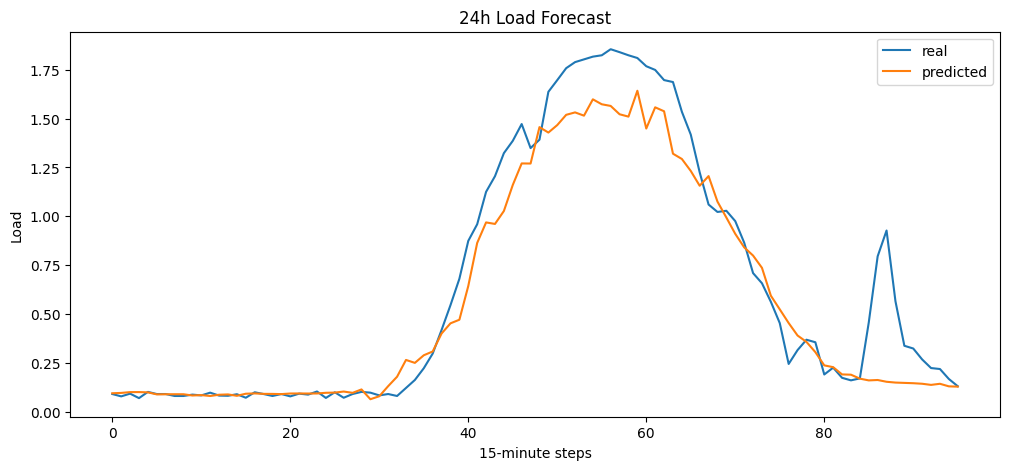

In [36]:
# ---------------------------------------------------------
# 34. Plot one full 24-hour forecast example
# ---------------------------------------------------------
sample = 200

plt.figure(figsize=(12, 5))
plt.plot(y_val.iloc[sample].values, label="real")
plt.plot(y_val_pred[sample], label="predicted")
plt.title("24h Load Forecast")
plt.xlabel("15-minute steps")
plt.ylabel("Load")
plt.legend()
plt.show()

In [37]:
# ---------------------------------------------------------
# 35. Define hyperparameter search space
# ---------------------------------------------------------
param_grid = [
    {
        "n_estimators": 100,
        "learning_rate": 0.05,
        "num_leaves": 31,
        "max_depth": -1,
        "min_child_samples": 20,
        "subsample": 1.0,
        "colsample_bytree": 1.0
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "num_leaves": 31,
        "max_depth": -1,
        "min_child_samples": 20,
        "subsample": 1.0,
        "colsample_bytree": 1.0
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.03,
        "num_leaves": 63,
        "max_depth": -1,
        "min_child_samples": 20,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "n_estimators": 300,
        "learning_rate": 0.03,
        "num_leaves": 63,
        "max_depth": 10,
        "min_child_samples": 30,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    }
]


In [38]:
# ---------------------------------------------------------
# 36. Run hyperparameter tuning on validation set
# ---------------------------------------------------------
tuning_results = []

for i, params in enumerate(param_grid, start=1):
    print(f"Running config {i}/{len(param_grid)} ...")

    model = MultiOutputRegressor(
        LGBMRegressor(
            random_state=42,
            verbosity=-1,
            **params
        )
    )

    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)

    mae = mean_absolute_error(y_val.values.flatten(), y_val_pred.flatten())
    rmse = np.sqrt(mean_squared_error(y_val.values.flatten(), y_val_pred.flatten()))

    row = params.copy()
    row["MAE"] = mae
    row["RMSE"] = rmse
    tuning_results.append(row)

tuning_results_df = pd.DataFrame(tuning_results).sort_values("RMSE")
display(tuning_results_df)

Running config 1/4 ...
Running config 2/4 ...
Running config 3/4 ...
Running config 4/4 ...


,n_estimators,learning_rate,num_leaves,max_depth,min_child_samples,subsample,colsample_bytree,MAE,RMSE
0,100,0.05,31,-1,20,1.0,1.0,0.144130,0.255812
2,200,0.03,63,-1,20,0.8,0.8,0.144138,0.257748
1,200,0.05,31,-1,20,1.0,1.0,0.145029,0.261022
3,300,0.03,63,10,30,0.8,0.8,0.145269,0.261299


In [39]:
# ---------------------------------------------------------
# 37. Retrain final model on train + validation sets
# ---------------------------------------------------------
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

final_model = MultiOutputRegressor(
    LGBMRegressor(
        n_estimators=100,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        subsample=1.0,
        colsample_bytree=1.0,
        random_state=42,
        verbosity=-1
    )
)

final_model.fit(X_train_full, y_train_full)

MultiOutputRegressor(estimator=LGBMRegressor(learning_rate=0.05,
                                             random_state=42, verbosity=-1))

In [40]:
# ---------------------------------------------------------
# 38. Evaluate final tuned model on test set
# ---------------------------------------------------------
y_test_pred = final_model.predict(X_test)

mae_test = mean_absolute_error(y_test.values.flatten(), y_test_pred.flatten())
rmse_test = np.sqrt(mean_squared_error(y_test.values.flatten(), y_test_pred.flatten()))

print("TEST MAE:", mae_test)
print("TEST RMSE:", rmse_test)

TEST MAE: 0.1126189680696487
TEST RMSE: 0.1997424047882482


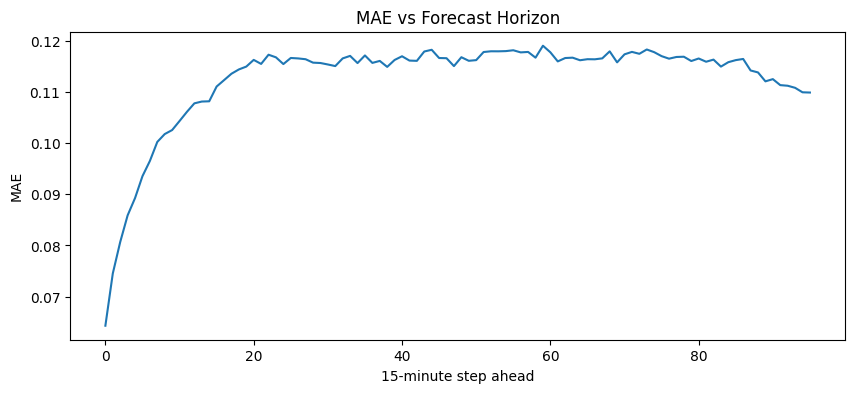

In [41]:
# ---------------------------------------------------------
# 39. Analyze test error across the full forecast horizon
# ---------------------------------------------------------
mae_per_step_test = []

for h in range(horizon):
    mae_h = mean_absolute_error(y_test.iloc[:, h], y_test_pred[:, h])
    mae_per_step_test.append(mae_h)

plt.figure(figsize=(10, 4))
plt.plot(mae_per_step_test)
plt.title("MAE vs Forecast Horizon")
plt.xlabel("15-minute step ahead")
plt.ylabel("MAE")
plt.show()

In [42]:
# ---------------------------------------------------------
# 40. Save final model for later HEMS integration
# ---------------------------------------------------------
joblib.dump(final_model, "../models/load_forecast_model.pkl")

['../models/load_forecast_model.pkl']

In [43]:
# ---------------------------------------------------------
# 41. Reload model to verify persistence
# ---------------------------------------------------------
model = joblib.load("../models/load_forecast_model.pkl")

In [44]:
# ---------------------------------------------------------
# 42. Define inference helper function
# ---------------------------------------------------------
def predict_next_24h_load(model, feature_row):
    pred = model.predict(feature_row)
    return pred.flatten()